## 1. Carga de Datos

El dataset se compone de dos archivos: transacciones e información de identidad.
No todas las transacciones tienen registros de identidad asociados, por lo que usamos
un left join para preservar el historial completo de transacciones. Las filas sin
datos de identidad tendrán NaN en esas columnas — comportamiento esperado e informativo.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#Establezco un estilo visual de los graficos
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 5)


def load_data(transaction_path: str, identity_path: str) -> pd.DataFrame:
    """
    Loads and merges transaction and identity datasets.

    Args:
        transaction_path: Path to train_transaction.csv
        identity_path: Path to train_identity.csv

    Returns:
        Merged DataFrame with all transactions and available identity features.
        Identity columns will be NaN where no match exists (expected behavior).
    """
    transactions = pd.read_csv(transaction_path)
    identity = pd.read_csv(identity_path)
    #Aqui uno las dos tablas por ID
    return transactions.merge(identity, on='TransactionID', how='left')


df = load_data('data/train_transaction.csv', 'data/train_identity.csv')
print(f"Dataset shape: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Dataset shape: (590540, 434)
Memory usage: 2636.1 MB


## 2. Análisis del Target: Distribución de Fraude

Antes de cualquier modelado, es crítico entender el desbalanceo de clases.
Un modelo que prediga siempre "no fraude" alcanzaría ~96.5% de accuracy — una
métrica completamente engañosa. Por eso usamos AUC-ROC como métrica principal.

=== Target Distribution ===
Legitimate transactions: 569,877 (96.50%)
Fraudulent transactions:  20,663 (3.50%)
Imbalance ratio: 27.6:1


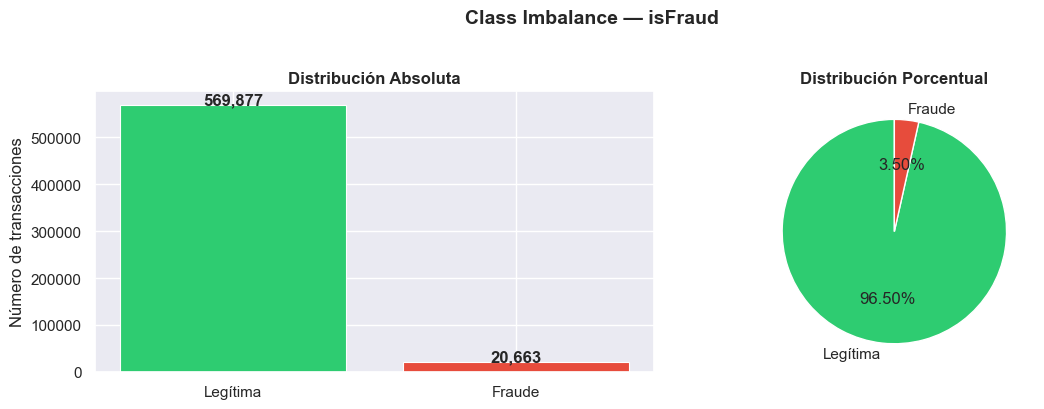

In [12]:
def plot_fraud_distribution(df: pd.DataFrame) -> None:
    """
    Visualizes the class imbalance in the target variable.

    Args:
        df: Merged transaction DataFrame with isFraud column
    """
    counts = df['isFraud'].value_counts()
    percentages = df['isFraud'].value_counts(normalize=True) * 100

    print("=== Target Distribution ===")
    print(f"Legitimate transactions: {counts[0]:,} ({percentages[0]:.2f}%)")
    print(f"Fraudulent transactions:  {counts[1]:,} ({percentages[1]:.2f}%)")
    print(f"Imbalance ratio: {counts[0]/counts[1]:.1f}:1")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].bar(['Legítima', 'Fraude'], counts.values,
                color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=0.8)
    axes[0].set_title('Distribución Absoluta', fontweight='bold')
    axes[0].set_ylabel('Número de transacciones')
    for i, v in enumerate(counts.values):
        axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

    axes[1].pie(counts.values, labels=['Legítima', 'Fraude'],
                colors=['#2ecc71', '#e74c3c'], autopct='%1.2f%%',
                startangle=90, wedgeprops={'edgecolor': 'white'})
    axes[1].set_title('Distribución Porcentual', fontweight='bold')

    plt.suptitle('Class Imbalance — isFraud', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('outputs/figures/01_fraud_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_fraud_distribution(df)